# Setup

In [1]:
from IPython.display import clear_output
!pip install keras==2.15
!pip install tensorflow==2.15
!git clone https://github.com/yunama47/Klasifikasi-Mammografi modul
clear_output()
print("-- dependency installs completed --")

-- dependency installs completed --


In [8]:
import os
import keras
import zipfile
import shutil
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from modul import mmv_model
from glob import glob

os.makedirs("/models", exist_ok=True)
for zippath in glob("/kaggle/input/*/*_models.zip"):
    with zipfile.ZipFile(zippath) as z:
        z.extractall("/models")
for src in glob("/models/*.h5"):
    if "model_mmv" in src:
        dst = src.replace("model_mmv","model_mmv_re")
        shutil.move(src, dst)
        
PREDICTIONS = {}
if os.path.exists("PREDICTION.npz"):
    loaded_npz = dict(np.load("PREDICTION.npz", allow_pickle=True))
    PREDICTIONS = {key:val[()] for key, val in loaded_npz.items()}
elif os.path.exists("/kaggle/input/test-model/PREDICTION.npz"):
    loaded_npz = dict(np.load("/kaggle/input/test-model/PREDICTION.npz", allow_pickle=True))
    PREDICTIONS = {key:val[()] for key, val in loaded_npz.items()}

recommended_action_classes = ['"tidak ada follow-up"', '"follow-up"', '"biopsy"']
fusion_names = {"1":"1-early-fusion", "2":"2-middle-fusion", "3":"3-last-fusion"}

params_values_map = {
    "learning_rate":("lr", float),
    "fusion" : ("fusion_stage", int),
    "pooling": ("pooling", str),
    "fc_depth" : ("fc_layers_depth", int),
    "fc_dims" : ("fc_layers_dims", int),
    "dropout_rate" : ("dropout_rate", float),
    "batch_size" : ("batch_size", int),
    "dataset":("dataset_type", str),
    "K-folds": ("k", int),
}
params_names = [pn for pn,_ in params_values_map.values()]

print(tf.__version__)
print(keras.__version__)
strategy = tf.distribute.MirroredStrategy()
def edit_label(img, labels):
    birads = labels['birads']
    recommended_action = tf.clip_by_value(tf.math.argmax(birads), 1, 3)
    recommended_action = tf.one_hot(int(recommended_action-1), 3)
    labels = {"birads":birads, "recommended_action":recommended_action}
    return img, labels

ds = tf.data.Dataset.load("/kaggle/input/dataset-primer/saved_ds").map(edit_label)
ds

2.15.0
2.15.0


<_MapDataset element_spec=({'CC': TensorSpec(shape=(512, 288, 3), dtype=tf.float32, name=None), 'MLO': TensorSpec(shape=(512, 288, 3), dtype=tf.float32, name=None)}, {'birads': TensorSpec(shape=(5,), dtype=tf.float32, name=None), 'recommended_action': TensorSpec(shape=(3,), dtype=tf.float32, name=None)})>

# Viz

BI-RADS 2 | "tidak ada follow-up"


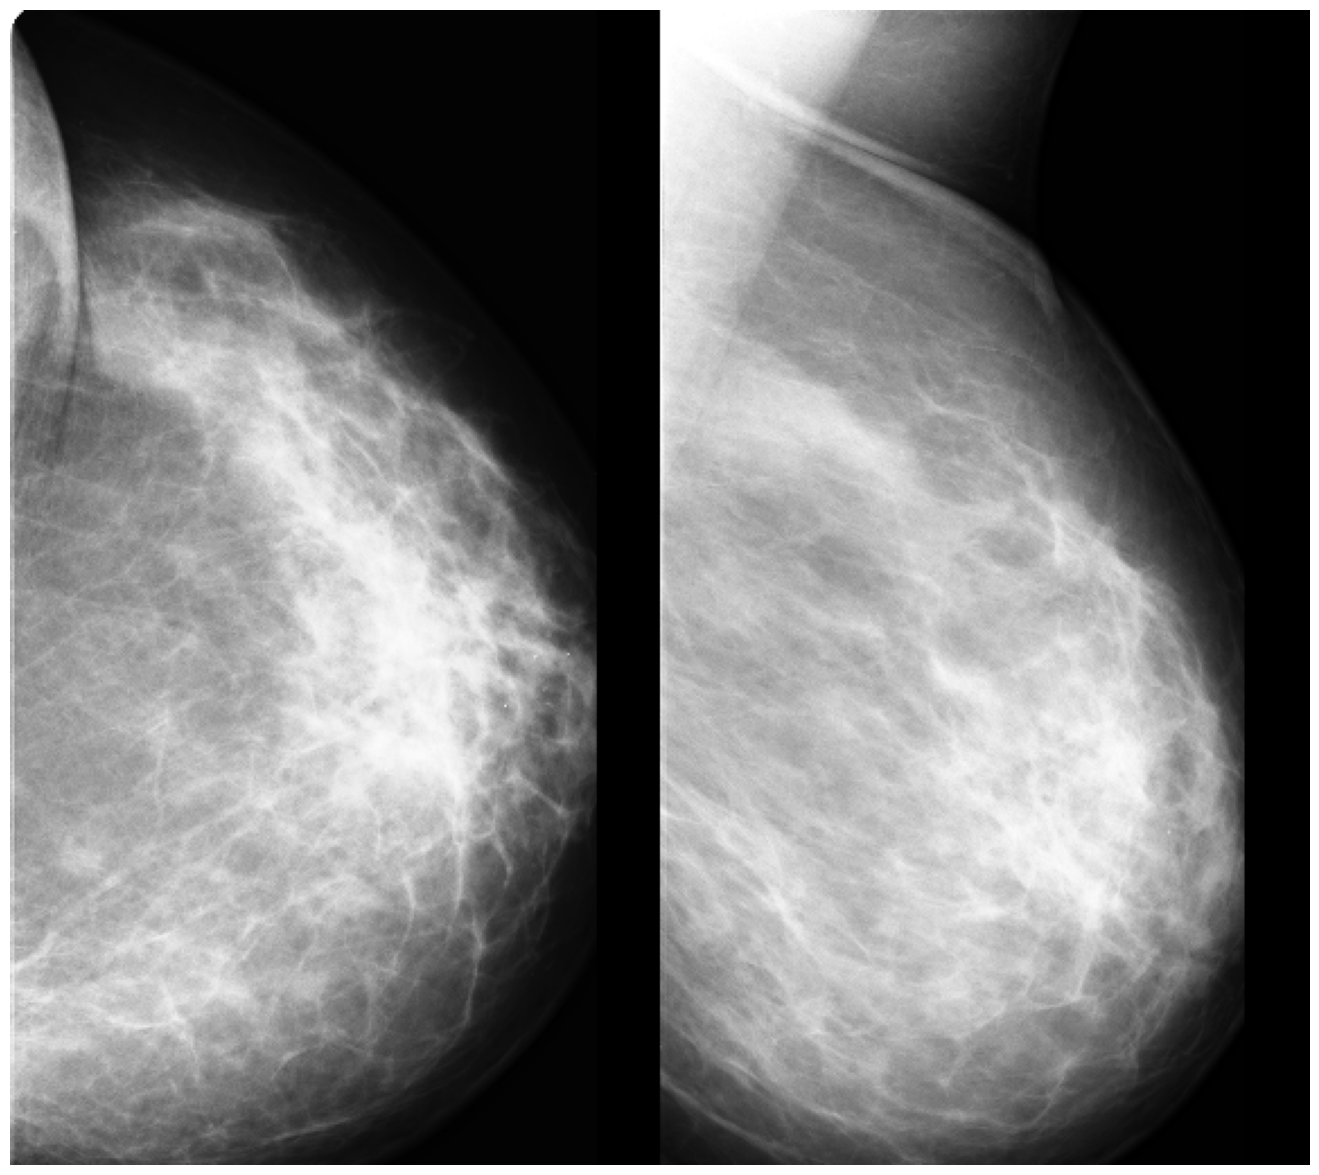

In [9]:
fig , ax = plt.subplots(1, 1, figsize=(20,15))
# ax = ax.flatten()
ax = [ax]
i = 0
for x, y in ds.shuffle(200).take(1):
    img = np.hstack((x['CC'].numpy().astype('uint8'),x['MLO'].numpy().astype('uint8')))
    ax[i].imshow(img)
    ax[i].axis('off')
    # ax[i].set_title(f"BI-RADS {np.argmax(y['birads'])+1} | {recommended_action_classes[np.argmax(y['recommended_action'].numpy())]}")
    print(f"BI-RADS {np.argmax(y['birads'])+1} | {recommended_action_classes[np.argmax(y['recommended_action'].numpy())]}")
    i+=1
plt.show()

# y true

In [10]:
birads_label = np.array(list(ds.map(lambda x, y: y["birads"]).as_numpy_iterator()))
recommended_action_label = np.array(list(ds.map(lambda x, y: y["recommended_action"]).as_numpy_iterator()))
# print(birads_label[:10])
# print(recommended_action_label[:10])
ds = ds.batch(11).prefetch(tf.data.AUTOTUNE)

In [11]:
import re
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             roc_curve, 
                             auc, 
                             RocCurveDisplay,
                             log_loss
                            )

def metrics_eval(y_true, y_pred, class_names, title='evaluation result', plot=True):
    assert len(class_names) >= 2
    metrics = ['accuracy','f1-score', 'loss','precission','recall', 'roc_auc']
    if len(class_names)>2:
        y_true1 = np.argmax(y_true, axis=-1).astype(int)
        y_pred1 = np.argmax(y_pred, axis=-1).astype(int)
    else:
        y_true1 = y_true.astype(int)
        y_pred1 = (y_pred>0.5).astype(int)
    conf_matrix = confusion_matrix(y_true1, y_pred1)
    metric_scores =[
                    accuracy_score(y_true1,y_pred1),
                    f1_score(y_true1,y_pred1, average='macro', zero_division=0),
                    log_loss(y_true, y_pred),
                    precision_score(y_true1,y_pred1, average='macro', zero_division=0),
                    recall_score(y_true1,y_pred1, average='macro', zero_division=0),
                    roc_auc_score(y_true, y_pred),
                    ]
    metric_scores_map = {metric:score for metric, score in zip(metrics, metric_scores)}
    if plot:
        color1 = (160,255,160)
        color2 = (255,160,160)
        custom_cmap = [[color1 if i==j else color2 for i in range(len(class_names))] for j in range(len(class_names))]
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        # == confusion matrix ==
        ax1.imshow(custom_cmap)
        ax1.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right')
        ax1.set_yticks(range(len(class_names)), class_names)
        ax1.set_xlabel('Predicted Label')
        ax1.set_ylabel('True Label')
        ax1.set_title('Confusion Matrix')
        for i in range(len(class_names)):  # Add annotations for each cell
            for j in range(len(class_names)):
                text = ax1.text(j, i, conf_matrix[i, j], ha='center', va='center', fontsize=10)
        # roc-auc curve
        if len(class_names) == 2:
            roc_auc = metric_scores_map["roc_auc"]
            fpr, tpr, _ = roc_curve(y_true, y_pred)
            display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="benign classifier")
            display.plot(ax2)
        else:
            for i, class_name in enumerate(class_names):
                true = y_true[:, i]
                pred = y_pred[:, i]
                fpr, tpr, _ = roc_curve(true, pred)
                roc_auc = auc(fpr, tpr)
                display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f"{class_name} classifier")
                display.plot(ax2)
        ax2.set_title(f"ROC-AUC curve (mean AUC = {metric_scores[-1]:.4f})")
        fig.suptitle(title)
        plt.show()
    
    return metric_scores_map

def process_preds(preds, plot, model_name,weight, recommended_action_func="sum", tres=None, ensemble_type="probs"):
    results = []
    birads_pred = preds["birads"].copy()
    preds["birads"] = preds["birads"] * weight
    recommended_action_pred = preds["birads"][:,1:4].copy()
    recommended_action_func = getattr(np, recommended_action_func)
    recommended_action_pred[:,0]=recommended_action_func(preds["birads"][:,0:2], axis=-1)
    recommended_action_pred[:,-1]=recommended_action_func(preds["birads"][:,3:5], axis=-1)
    if ensemble_type=="logits":
        birads_pred = tf.nn.softmax(birads_pred).numpy()
        recommended_action_pred = tf.nn.softmax(recommended_action_pred).numpy()
    if tres:
        birads_pred = (birads_pred>=tres).astype(int)
        recommended_action_pred = (recommended_action_pred>=tres).astype(int)
    scores_recommended_action = metrics_eval(recommended_action_label, recommended_action_pred, recommended_action_classes, plot=plot, title=f"{model_name} recommended_action label")
    scores_birads = metrics_eval(birads_label, birads_pred, [f'BI-RADS {i}' for i in range(1,6)], plot=plot, title=f"{model_name} birads label")
    results.append({"model_name":model_name,
                    "label_name":"birads",
                    **scores_birads
                   })
    results.append({"model_name":model_name,
                    "label_name":"recommended_action",
                    **scores_recommended_action
                   })
    return results
    
def evaluate_models(path_patterns, labels=["birads"], plot=True,tres=0.5, 
                    weight=np.ones(shape=5), ensemble_all=False, overwrite=False,
                    ensemble_kfolds=True, verbose=1, recommended_action_func='sum',
                    ensemble_type="probs",):
    global PREDICTIONS
    scanned_paths = []
    for pattern in path_patterns:
        scanned_paths.extend(glob(pattern))
    model_patterns = []
    results = []
    for model_pattern in sorted(scanned_paths):
        if ensemble_kfolds:
            model_pattern = re.sub(r'fold[-0-9]+', 'fold*', model_pattern)
        model_pattern = re.sub(r'input/[a-z-0-9]+', 'input/*', model_pattern)
        model_pattern = re.sub(r'repeat[.0-9]+', 'repeat*', model_pattern)
        # for param in params_names:
        #     model_pattern = re.sub(f'{param}[_.0-9a-z]+', param+'*', model_pattern)
        model_patterns.append(model_pattern) 
    model_patterns = np.unique(model_patterns)
    all_preds = {label:[] for label in labels}
    model = None
    for i, model_pattern in enumerate(sorted(model_patterns, reverse=False)):
        if verbose:
            print(f"\n{i+1}/{len(model_patterns)} :", model_pattern)
        labels_preds = {label:[] for label in labels}
        for model_path in sorted(glob(model_pattern), reverse=False):
            fold_name = os.path.basename(model_path).removesuffix(".h5")
            if verbose:
                print(fold_name)
            preds = PREDICTIONS.get(fold_name)
            if preds is None or overwrite:
                if model is None:
                    model = keras.models.load_model(model_path)
                else:
                    try:
                        model.load_weights(model_path)
                    except:
                        model = keras.models.load_model(model_path)
                preds = model.predict(ds, verbose=verbose)
                PREDICTIONS[fold_name] = preds
                tf.keras.backend.clear_session()
            for label in labels:
                if ensemble_type=="logits":
                    labels_preds[label].append(preds[label])
                elif ensemble_type=="probs":
                    labels_preds[label].append(tf.nn.softmax(preds[label]).numpy())
                else:
                    raise Exception("ensemble_type only 'probs' or 'logits'")
        for label in labels:
            labels_preds[label] = np.mean(labels_preds[label], axis=0) #* weight
            all_preds[label].append(labels_preds[label])
        model_name = fold_name
        if ensemble_kfolds:
            model_name = re.sub(r'_fold[-0-9]+', '', model_name)
        model_name = re.sub(r'model_mmv_', '', model_name)
        model_name = re.sub(r'repeat[.0-9]+', 'repeat', model_name)
        #==================================
        results.extend(process_preds(labels_preds, plot, model_name,weight=weight,recommended_action_func=recommended_action_func, tres=tres,ensemble_type=ensemble_type))
    np.savez("PREDICTION.npz", **PREDICTIONS)
    if ensemble_all:
        all_preds["birads"] = np.mean(all_preds["birads"], axis=0)
        results.extend(process_preds(all_preds, plot, "ensemble_all",weight=weight,recommended_action_func=recommended_action_func, tres=tres,ensemble_type=ensemble_type))
    return pd.DataFrame(results)
0

0

In [12]:
label_weight = np.array([
    0.5, #BIRADS 1
    0.5, #BIRADS 2
    1.0, #BIRADS 3
    0.5, #BIRADS 4
    0.5, #BIRADS 5
]) * 0 + 1

results = evaluate_models([     
                           "/kaggle/input/*/mmv_model*.h5",
                          ], 
                          plot=False, tres=None, weight=label_weight, ensemble_all=False, overwrite=False, 
                          ensemble_kfolds=True, verbose=1, recommended_action_func='sum',ensemble_type="probs")

results_recommended_action = results.loc[results.label_name=="recommended_action",:]
results_birads = results.loc[results.label_name=="birads",:]
results_birads.set_index("model_name").to_csv("results_birads.csv")
results_recommended_action.set_index("model_name").to_csv("results_recommended_action.csv")
#True  False


1/8 : /kaggle/input/*/mmv_model0_fold*.h5
mmv_model0_fold-0


I0000 00:00:1738826583.728080     125 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 [==============================] - 16s 419ms/step
mmv_model0_fold-1
10/10 [==============================] - 7s 416ms/step
mmv_model0_fold-2
10/10 [==============================] - 7s 417ms/step
mmv_model0_fold-3
10/10 [==============================] - 7s 420ms/step
mmv_model0_fold-0
mmv_model0_fold-1
mmv_model0_fold-2
mmv_model0_fold-3

2/8 : /kaggle/input/*/mmv_model1_fold*.h5
mmv_model1_fold-0
10/10 [==============================] - 7s 417ms/step
mmv_model1_fold-1
10/10 [==============================] - 7s 417ms/step
mmv_model1_fold-2
10/10 [==============================] - 7s 417ms/step
mmv_model1_fold-3
10/10 [==============================] - 7s 417ms/step
mmv_model1_fold-0
mmv_model1_fold-1
mmv_model1_fold-2
mmv_model1_fold-3

3/8 : /kaggle/input/*/mmv_model2_fold*.h5
mmv_model2_fold-0
10/10 [==============================] - 7s 417ms/step
mmv_model2_fold-1
10/10 [==============================] - 7s 417ms/step
mmv_model2_fold-2
10/10 [==============================] 

In [13]:
top_f1_birads = results_birads.sort_values(by="f1-score", ascending=False).drop("label_name", axis=1).set_index("model_name")
display(top_f1_birads)
top_f1_birads.sort_values(by="f1-score", ascending=False).describe()

,accuracy,f1-score,loss,precission,recall,roc_auc
model_name,,,,,,
mmv_model6,0.509091,0.476649,1.289714,0.512155,0.457972,0.676988
mmv_model0,0.518182,0.459890,1.345431,0.528724,0.455058,0.622766
mmv_model1,0.418182,0.424352,1.363935,0.444422,0.412937,0.706358
mmv_model5,0.472727,0.423520,1.305955,0.470152,0.398508,0.724609
mmv_model2,0.472727,0.421408,1.311664,0.489111,0.427203,0.687917
mmv_model3,0.518182,0.403751,1.356601,0.406984,0.438275,0.706011
mmv_model4,0.390909,0.401578,1.446591,0.462865,0.371585,0.675438
mmv_model7,0.481818,0.401090,1.224507,0.441667,0.377249,0.710085


,accuracy,f1-score,loss,precission,recall,roc_auc
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.472727,0.426530,1.330550,0.469510,0.417348,0.688772
std,0.046609,0.027912,0.064757,0.039763,0.033132,0.031666
min,0.390909,0.401090,1.224507,0.406984,0.371585,0.622766
25%,0.459091,0.403208,1.301895,0.443733,0.393193,0.676600
50%,0.477273,0.422464,1.328547,0.466509,0.420070,0.696964
75%,0.511364,0.433237,1.358434,0.494872,0.442471,0.707289
max,0.518182,0.476649,1.446591,0.528724,0.457972,0.724609


In [14]:
top_f1_recommended_action = results_recommended_action.sort_values(by="f1-score", ascending=False).drop("label_name", axis=1).set_index("model_name")
display(top_f1_recommended_action)
top_f1_recommended_action.sort_values(by="f1-score", ascending=False).describe()

,accuracy,f1-score,loss,precission,recall,roc_auc
model_name,,,,,,
mmv_model6,0.718182,0.525103,0.758877,0.545849,0.511004,0.673361
mmv_model2,0.663636,0.470971,0.846088,0.463558,0.486312,0.635693
mmv_model1,0.763636,0.420112,0.795959,0.456349,0.418322,0.677808
mmv_model5,0.690909,0.414866,0.814487,0.413220,0.416532,0.677159
mmv_model7,0.709091,0.406215,0.741932,0.413300,0.404008,0.688669
mmv_model0,0.700000,0.405691,0.807539,0.392533,0.420648,0.569463
mmv_model3,0.709091,0.404768,0.827917,0.395588,0.414385,0.685507
mmv_model4,0.690909,0.389034,0.852983,0.382609,0.395777,0.642507


,accuracy,f1-score,loss,precission,recall,roc_auc
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,0.705682,0.429595,0.805723,0.432876,0.433374,0.656271
std,0.028722,0.045545,0.039270,0.054208,0.041640,0.040081
min,0.663636,0.389034,0.741932,0.382609,0.395777,0.569463
25%,0.690909,0.405460,0.786688,0.394824,0.411791,0.640804
50%,0.704545,0.410541,0.811013,0.413260,0.417427,0.675260
75%,0.711364,0.432826,0.832460,0.458151,0.437064,0.679733
max,0.763636,0.525103,0.852983,0.545849,0.511004,0.688669


In [15]:
with zipfile.ZipFile("/kaggle/input/convnext-multi-view-training-copy3/train_log.zip") as zr:
    all_model_cv = {}
    for model_name in results_birads["model_name"]:
        model_cv = pd.DataFrame()
        for i in range(4):
            try:
                fold_cv = pd.read_csv(zr.open(f"{model_name}_fold-{i}.csv"))
            except:
                fold_cv = pd.read_csv(f"/kaggle/input/model-training-outputs/train_log/{model_name}_fold-{i}.csv")
            best_cv = fold_cv[fold_cv["val_f1_score"]==fold_cv["val_f1_score"].max()].copy()
            model_cv = pd.concat((model_cv, best_cv))
        all_model_cv[model_name] = model_cv.mean()

all_model_cv = pd.DataFrame(all_model_cv).T
# all_model_cv["val_loss"] = 1/all_model_cv["val_loss"]
# top_f1_birads["loss"] = 1/top_f1_birads["loss"]
cv = all_model_cv.loc[:,"val_accuracy":].agg(['mean','min','std']).round(3).T
test = top_f1_birads.agg(['mean','min','std']).round(3).T

In [16]:
top_f1_birads

,accuracy,f1-score,loss,precission,recall,roc_auc
model_name,,,,,,
mmv_model6,0.509091,0.476649,1.289714,0.512155,0.457972,0.676988
mmv_model0,0.518182,0.459890,1.345431,0.528724,0.455058,0.622766
mmv_model1,0.418182,0.424352,1.363935,0.444422,0.412937,0.706358
mmv_model5,0.472727,0.423520,1.305955,0.470152,0.398508,0.724609
mmv_model2,0.472727,0.421408,1.311664,0.489111,0.427203,0.687917
mmv_model3,0.518182,0.403751,1.356601,0.406984,0.438275,0.706011
mmv_model4,0.390909,0.401578,1.446591,0.462865,0.371585,0.675438
mmv_model7,0.481818,0.401090,1.224507,0.441667,0.377249,0.710085


In [17]:
all_model_cv.loc[:,"val_accuracy":].sort_values(by="val_f1_score", ascending=False)

,val_accuracy,val_f1_score,val_loss,val_precision,val_recall,val_roc_auc
mmv_model6,0.353038,0.486220,1.042681,0.342265,0.610604,0.741539
mmv_model7,0.334135,0.469975,1.274268,0.296593,0.834375,0.741158
mmv_model2,0.331184,0.461001,1.199871,0.279791,0.714957,0.712702
mmv_model5,0.315887,0.449893,1.254344,0.325274,0.663007,0.735512
mmv_model0,0.320039,0.446352,1.169777,0.203966,0.657986,0.696223
mmv_model4,0.328016,0.442690,0.934043,0.387165,0.622863,0.757667
mmv_model3,0.318291,0.431485,1.121756,0.346758,0.543456,0.694334
mmv_model1,0.283982,0.383111,1.115828,0.177069,0.520059,0.629000


In [18]:
m = ["accuracy","f1_score","loss","precision","recall","roc_auc"]
pd.DataFrame(
    data=[
        [f"{mean:.3f} [{max:.3f}] ({std:.3f})" for mean, max, std in zip(test["mean"],test["min"],test["std"])],
        [f"{mean:.3f} [{max:.3f}] ({std:.3f})" for mean, max, std in zip(cv["mean"],cv["min"],cv["std"])]
    ],
    columns=m,
    index=["test", 'cv']
)

,accuracy,f1_score,loss,precision,recall,roc_auc
test,0.473 [0.391] (0.047),0.427 [0.401] (0.028),1.331 [1.225] (0.065),0.470 [0.407] (0.040),0.417 [0.372] (0.033),0.689 [0.623] (0.032)
cv,0.323 [0.284] (0.020),0.446 [0.383] (0.031),1.139 [0.934] (0.112),0.295 [0.177] (0.072),0.646 [0.520] (0.099),0.714 [0.629] (0.041)


In [19]:
with zipfile.ZipFile("/kaggle/input/convnext-multi-view-training-copy3/train_log.zip") as zr:
    model_name = "mmv_model6"
    model_cv = pd.DataFrame()
    for i in range(4):
        try:
            fold_cv = pd.read_csv(zr.open(f"{model_name}_fold-{i}.csv"))
        except:
            fold_cv = pd.read_csv(f"/kaggle/input/model-training-outputs/train_log/{model_name}_fold-{i}.csv")
        fold_cv["fold"] = f"fold-{i}"
        # best_cv = fold_cv[fold_cv["val_f1_score"]==fold_cv["val_f1_score"].max()].copy()
        model_cv = pd.concat((model_cv, fold_cv))
model_cv.set_index("fold")#loc[:,"val_accuracy":].sort_values(by="val_f1_score", ascending=False)

,epoch,accuracy,f1_score,loss,precision,recall,roc_auc,val_accuracy,val_f1_score,val_loss,val_precision,val_recall,val_roc_auc
fold,,,,,,,,,,,,,
fold-0,0,0.133929,0.169292,1.315116,0.182927,0.142857,0.499469,0.134615,0.109197,1.107524,0.000000,0.000000,0.525149
fold-0,1,0.160714,0.207602,1.217816,0.231481,0.059524,0.519948,0.201923,0.177634,1.100091,0.750000,0.020833,0.540077
fold-0,2,0.189286,0.218069,1.194052,0.340909,0.071429,0.564022,0.163462,0.165990,1.109914,0.000000,0.000000,0.529840
fold-0,3,0.187500,0.221507,1.196282,0.369748,0.104762,0.530113,0.221154,0.184233,1.033119,0.553191,0.180556,0.626005
fold-0,4,0.223214,0.248152,1.161887,0.484127,0.145238,0.585100,0.259615,0.253533,1.002804,0.840000,0.145833,0.661748
...,...,...,...,...,...,...,...,...,...,...,...,...,...
fold-3,45,0.630068,0.862975,0.238616,0.592417,0.868056,0.925222,0.295455,0.407396,1.511017,0.348485,0.530769,0.711797
fold-3,46,0.667230,0.914265,0.198324,0.597542,0.900463,0.932854,0.284091,0.390946,1.554343,0.347368,0.507692,0.710976
fold-3,47,0.650338,0.890712,0.215374,0.601246,0.893519,0.929051,0.301136,0.415094,1.547649,0.345000,0.530769,0.708898


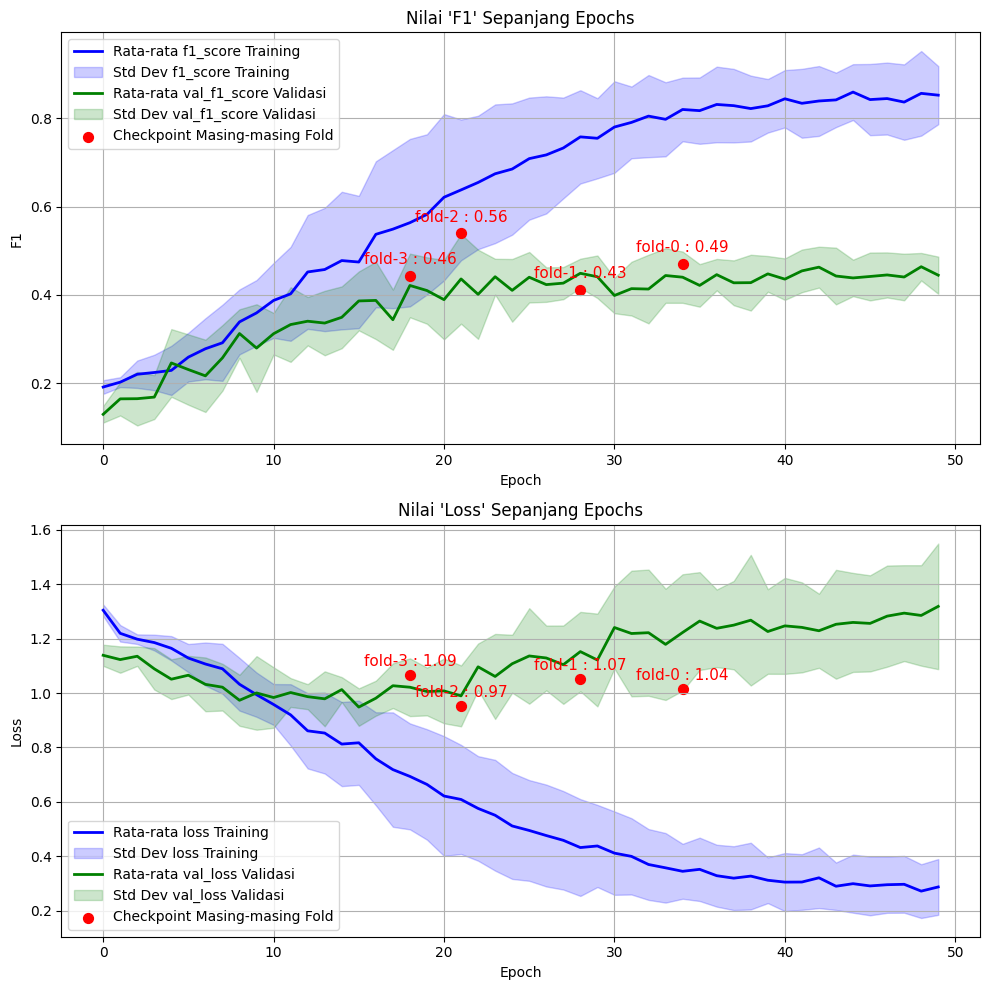

In [20]:
metrics = ['f1_score', 'val_f1_score', 'loss', 'val_loss']
plt.figure(figsize=(10, 10))
data = model_cv.copy()

for i, (train_metric, val_metric) in enumerate(zip(metrics[::2], metrics[1::2]), 1):
    plt.subplot(2, 1, i)

    grouped_train = data.groupby('epoch')[train_metric]
    grouped_val = data.groupby('epoch')[val_metric]

    # Convert values to numpy arrays for compatibility
    mean_train = grouped_train.mean().to_numpy()
    std_train = grouped_train.std().to_numpy()
    mean_val = grouped_val.mean().to_numpy()
    std_val = grouped_val.std().to_numpy()
    epochs = grouped_train.mean().index.to_numpy()

    # Fill NaN values with 0 for plotting
    mean_train = np.nan_to_num(mean_train)
    std_train = np.nan_to_num(std_train)
    mean_val = np.nan_to_num(mean_val)
    std_val = np.nan_to_num(std_val)

    # Plot training metric with shading
    plt.plot(epochs, mean_train, label=f"Rata-rata {train_metric} Training", color="blue", linewidth=2)
    plt.fill_between(epochs, mean_train - std_train, mean_train + std_train, 
                     color="blue", alpha=0.2, label=f"Std Dev {train_metric} Training")

    # Plot validation metric with shading
    plt.plot(epochs, mean_val, label=f"Rata-rata {val_metric} Validasi", color="green", linewidth=2)
    plt.fill_between(epochs, mean_val - std_val, mean_val + std_val, 
                     color="green", alpha=0.2, label=f"Std Dev {val_metric} Validasi")
    
    # Annotate best F1-score for each fold
    for fold, fold_data in data.groupby('fold'):
        best_epoch = fold_data.loc[fold_data['val_f1_score'].idxmax()]
        best_epoch_value = best_epoch['epoch']
        best_metric_score = best_epoch[val_metric]
    
        plt.scatter(best_epoch_value, best_metric_score-0.02, color="red", s=50, label="None")
        plt.text(best_epoch_value, best_metric_score, f"{fold} : {best_metric_score:.2f}", 
                 fontsize=11, ha="center", va="bottom", color="red")
        
    plt.title(f"Nilai '{train_metric.split('_')[0].capitalize()}' Sepanjang Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(train_metric.split('_')[0].capitalize())
    plt.legend([f"Rata-rata {train_metric} Training", f"Std Dev {train_metric} Training", 
            f"Rata-rata {val_metric} Validasi", f"Std Dev {val_metric} Validasi", 
            "Checkpoint Masing-masing Fold"])
    plt.grid()

plt.tight_layout()
plt.show()

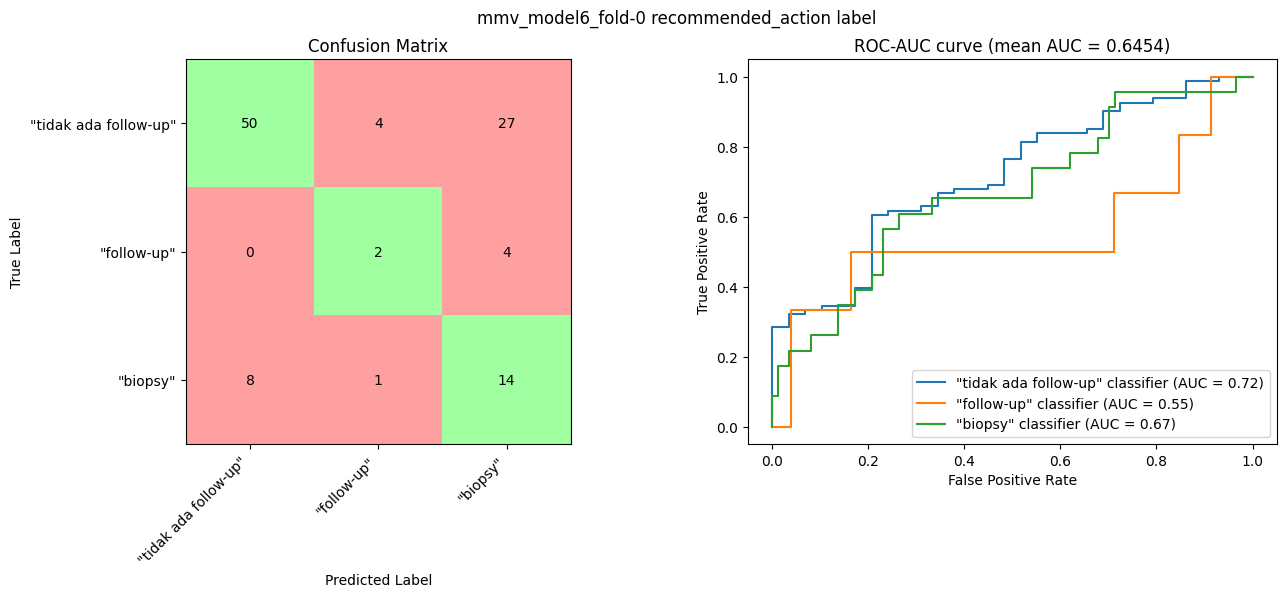

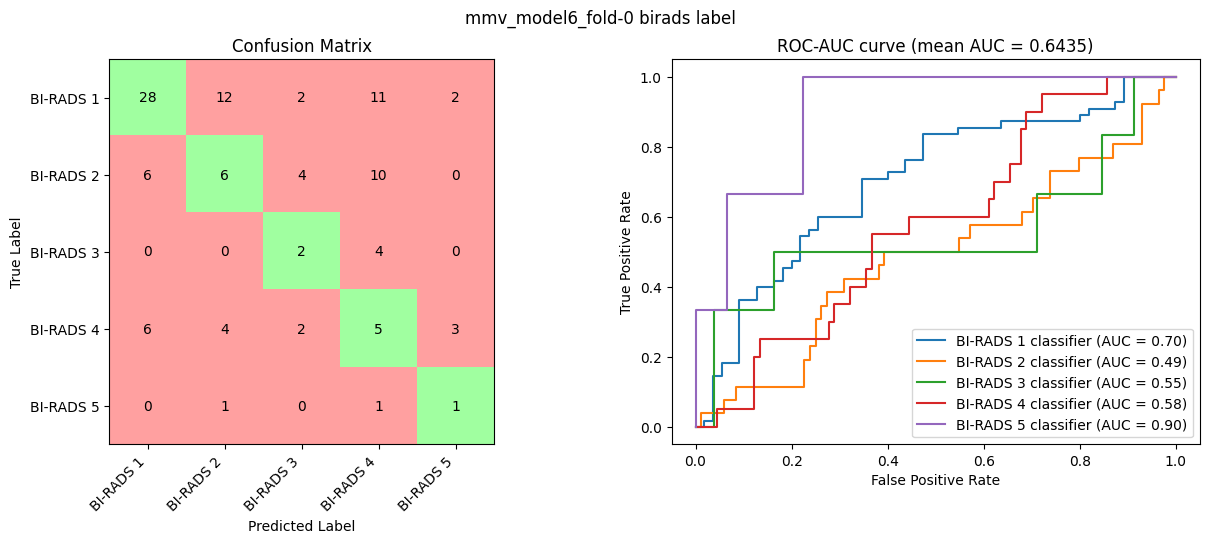

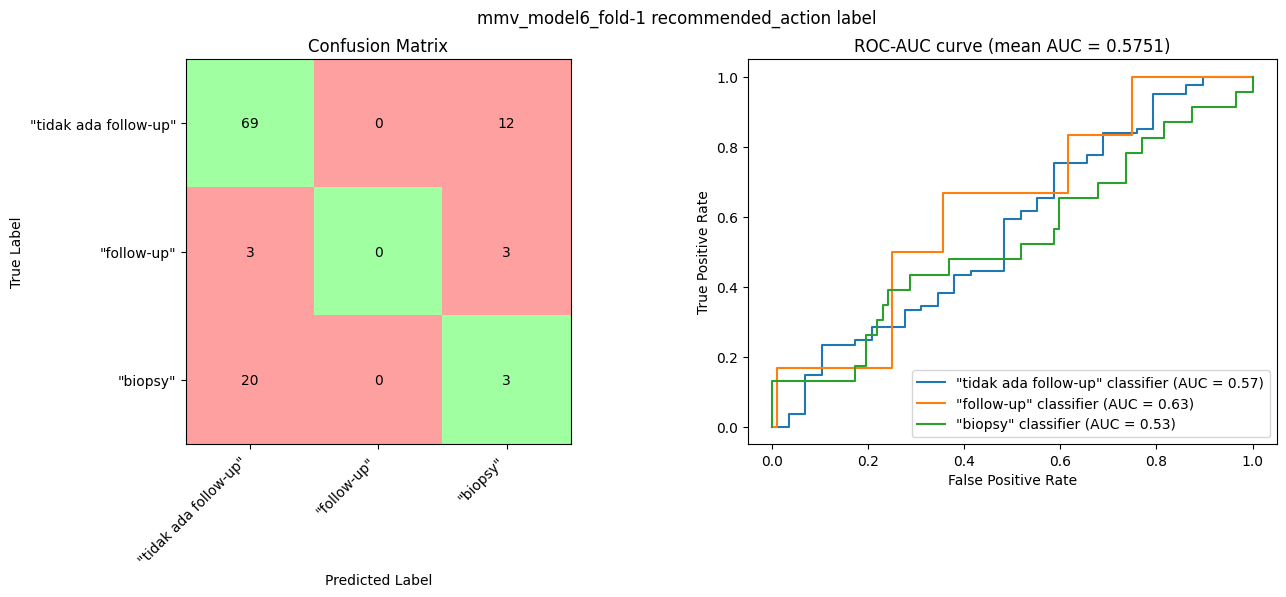

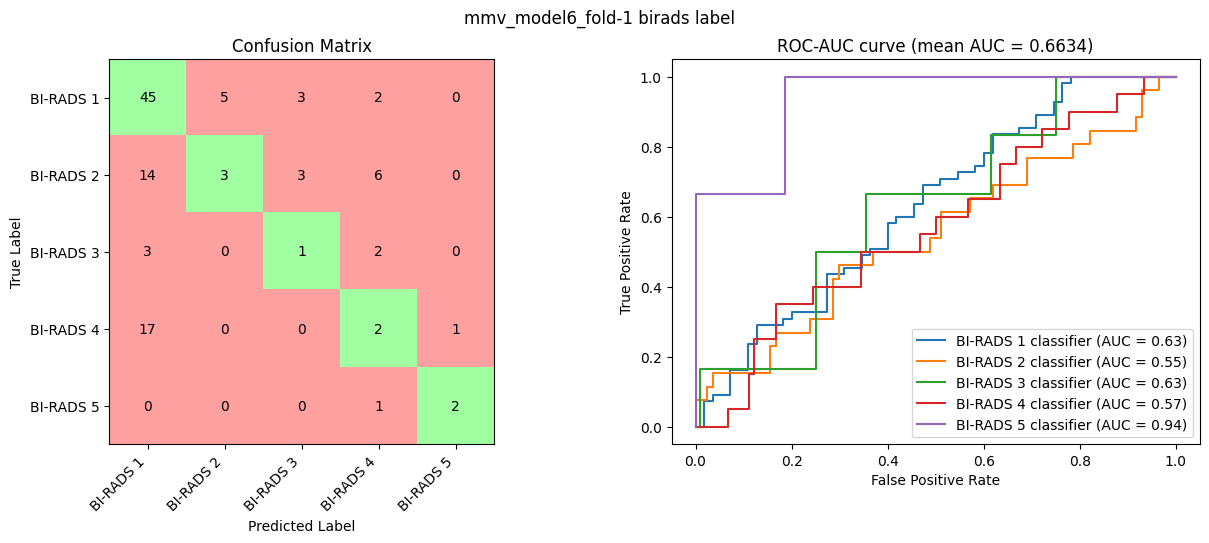

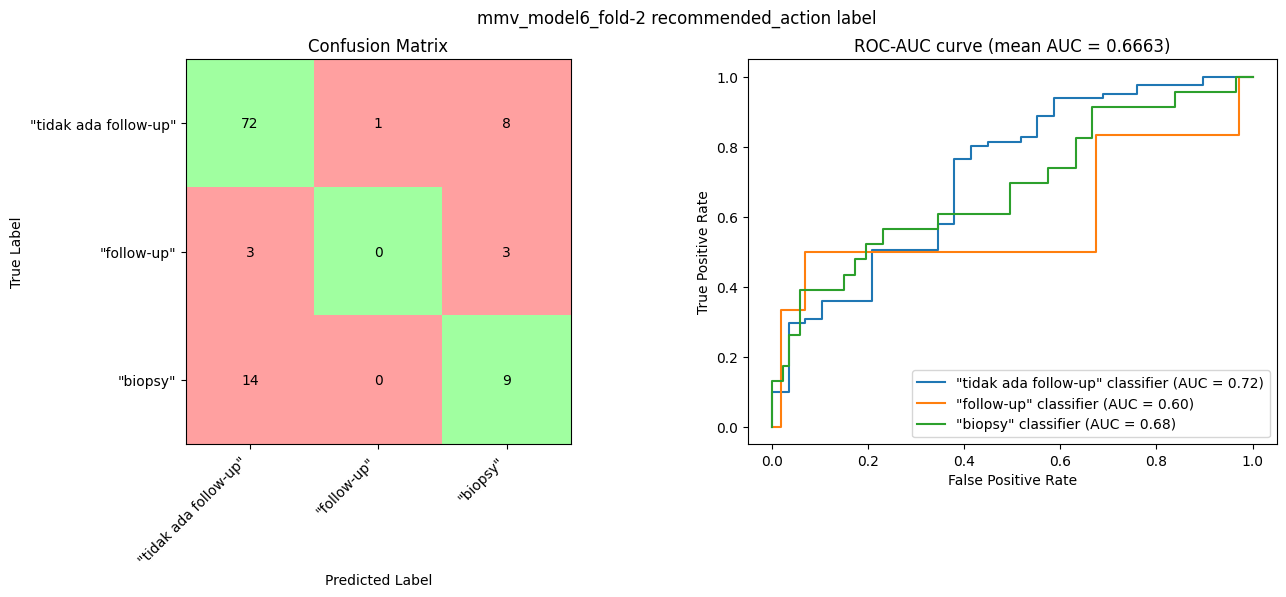

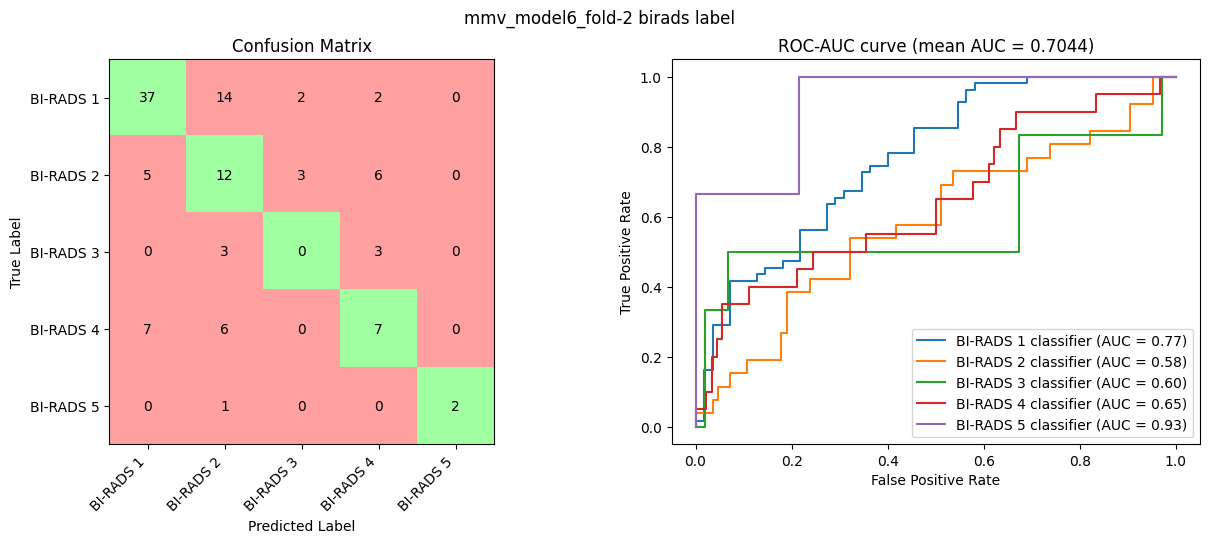

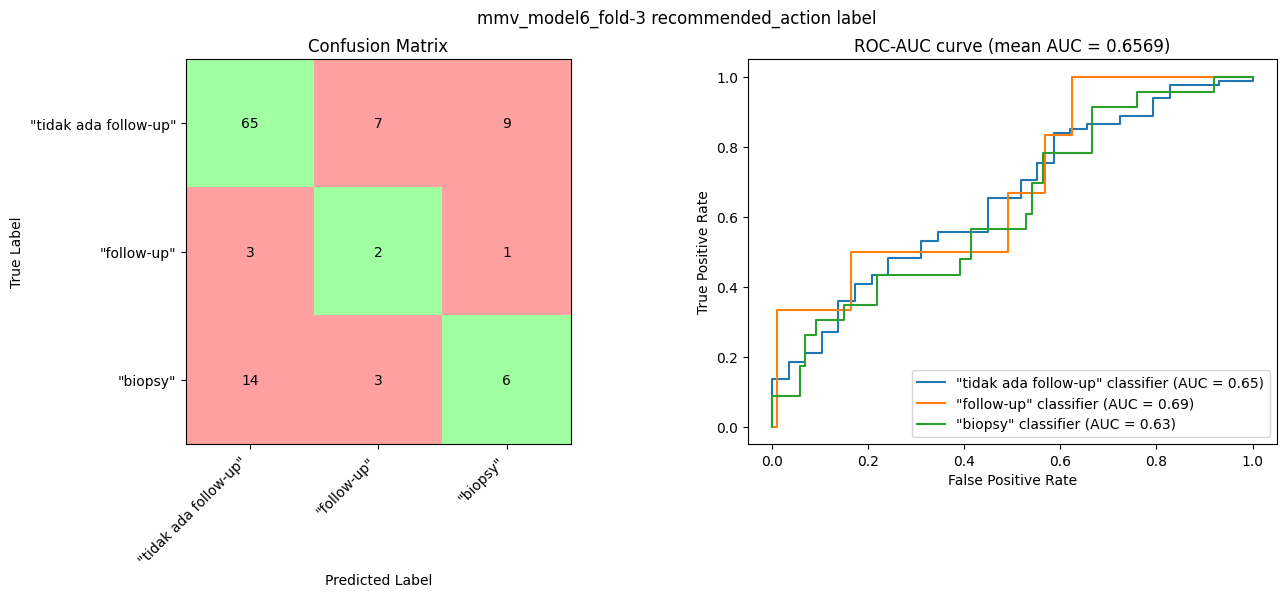

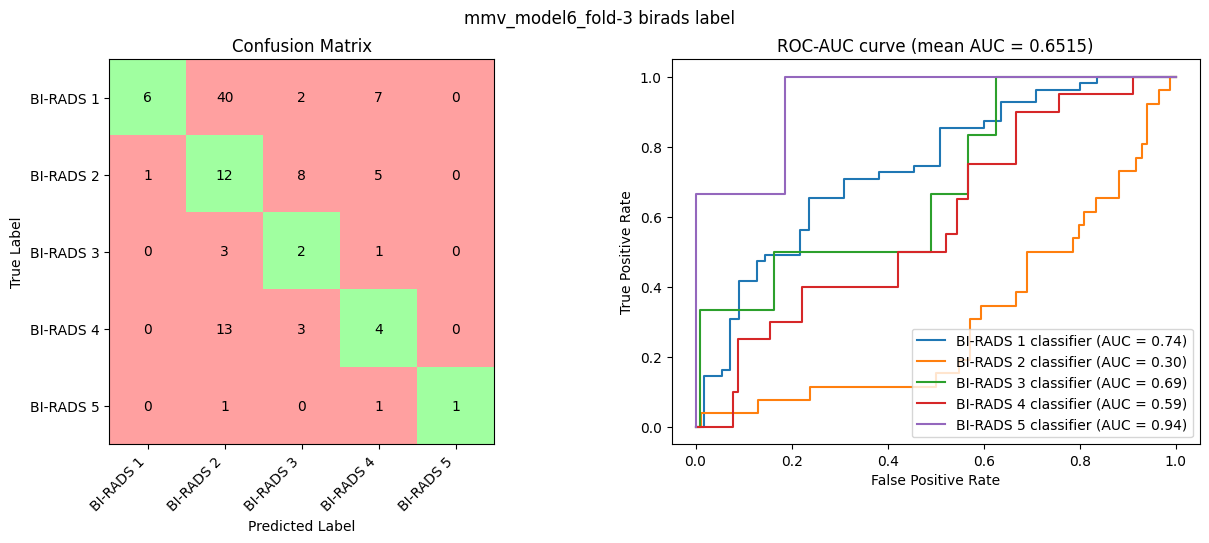

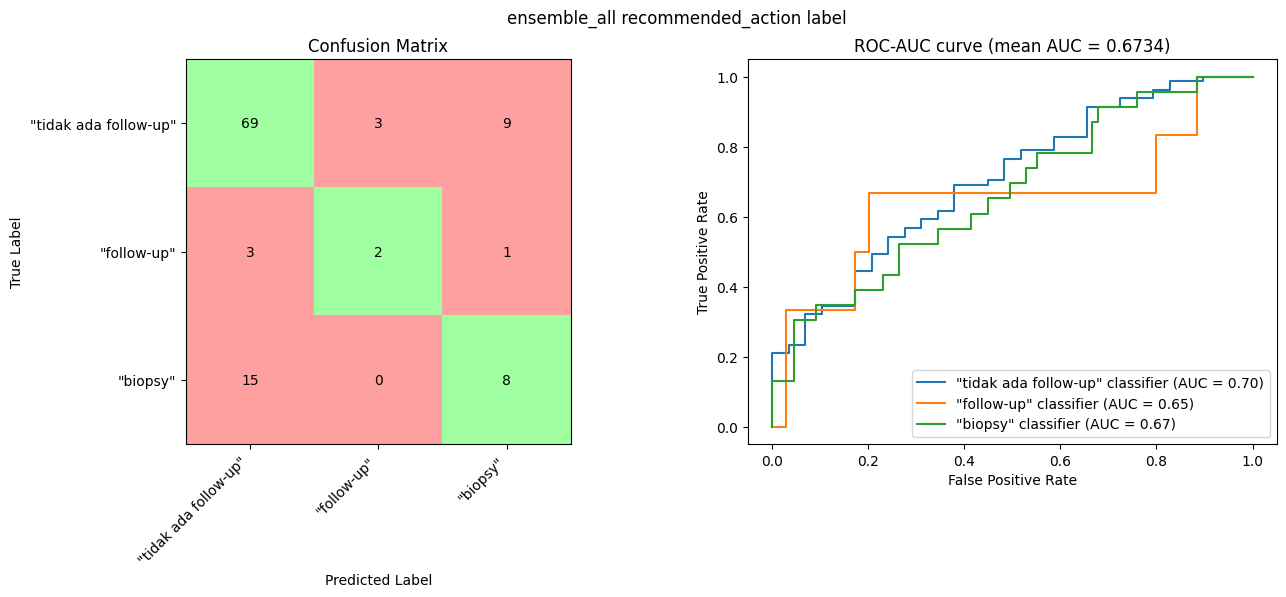

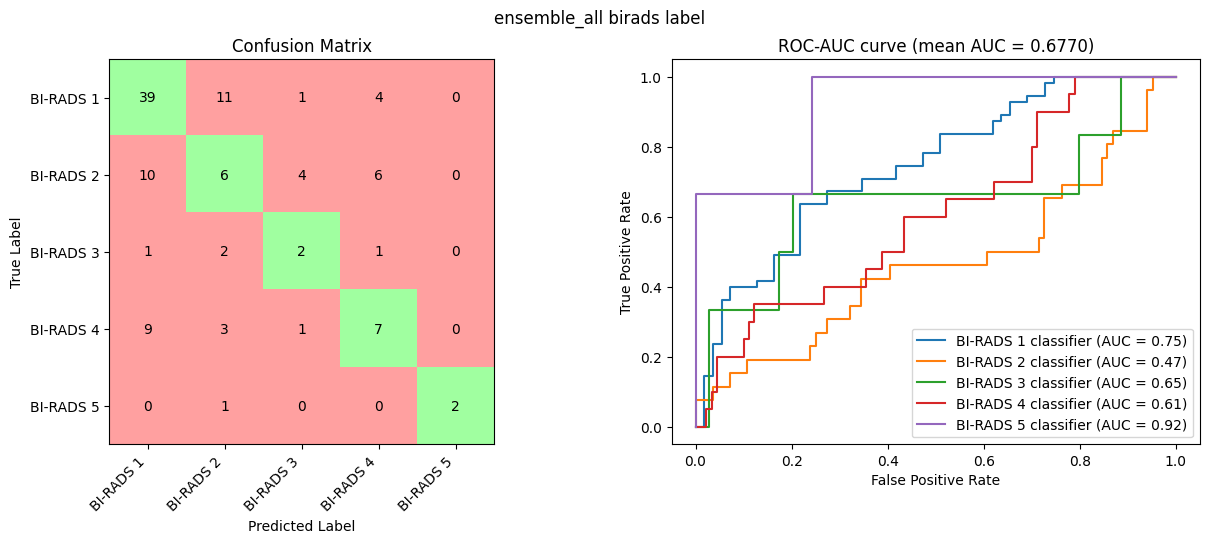

,model_name,label_name,accuracy,f1-score,loss,precission,recall,roc_auc
9,ensemble_all,recommended_action,0.718182,0.525103,0.758877,0.545849,0.511004,0.673361
1,mmv_model6_fold-0,recommended_action,0.600000,0.479627,0.889377,0.486298,0.519771,0.645430
7,mmv_model6_fold-3,recommended_action,0.663636,0.442487,0.926450,0.444783,0.465557,0.656895
5,mmv_model6_fold-2,recommended_action,0.736364,0.421888,0.712393,0.419663,0.426731,0.666324
3,mmv_model6_fold-1,recommended_action,0.654545,0.314676,0.808499,0.305556,0.327429,0.575071
8,ensemble_all,birads,0.509091,0.476649,1.289714,0.512155,0.457972,0.676988
4,mmv_model6_fold-2,birads,0.527273,0.453411,1.234672,0.495465,0.430186,0.704351
2,mmv_model6_fold-1,birads,0.481818,0.357967,1.300314,0.381598,0.373380,0.663416
0,mmv_model6_fold-0,birads,0.381818,0.300534,1.698040,0.297765,0.331305,0.643455
6,mmv_model6_fold-3,birads,0.227273,0.269436,1.630190,0.477322,0.287459,0.651512


In [22]:
evaluate_models([     
               "/kaggle/input/*/mmv_model6*.h5",
              ], 
              plot=True, tres=None, weight=label_weight, ensemble_all=True, overwrite=False, 
              ensemble_kfolds=False, verbose=0,recommended_action_func='sum',ensemble_type="probs").sort_values(by=["label_name","f1-score"],ascending=False)

In [ ]:
# import time;time.sleep(10000)

In [24]:
!rm -rf modul

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()
